# Tâche 2 — Régression Logistique avec Calibration

Ce notebook implémente uniquement la Tâche 2 :
- Entraînement d'une régression logistique multinomiale
- Calibration des probabilités (Platt `sigmoid` ou `isotonic`)
- Analyse des prédictions incertaines (`max_prob < 0.7`)

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import load_dataset_split
from src.data.preprocess import preprocess_dataset
from src.models.log_reg import flatten_images, train_logistic_regression, predict_with_confidence
from src.models.calibration import calibrate_classifier, summarize_confidence_distribution, analyze_uncertain_predictions

In [2]:
# Paramètres (mode rapide recommandé pour notebook)
DATA_DIR = PROJECT_ROOT / 'data'
TRAIN_DIR = DATA_DIR / 'Training'
TEST_DIR = DATA_DIR / 'Testing'
IMG_SIZE = (32, 32)
MAX_ITER = 200
CALIBRATION_METHOD = 'sigmoid'  # 'sigmoid' ou 'isotonic'
CV_FOLDS = 2
UNCERTAINTY_THRESHOLD = 0.7

assert TRAIN_DIR.exists(), f'Dossier introuvable: {TRAIN_DIR}'
assert TEST_DIR.exists(), f'Dossier introuvable: {TEST_DIR}'

print('TRAIN_DIR:', TRAIN_DIR)
print('TEST_DIR :', TEST_DIR)
print(f'IMG_SIZE={IMG_SIZE}, MAX_ITER={MAX_ITER}, METHOD={CALIBRATION_METHOD}, CV={CV_FOLDS}')

TRAIN_DIR: c:\Users\valen\Documents\EFREI\I2\Machine_Learning\Projet\data\Training
TEST_DIR : c:\Users\valen\Documents\EFREI\I2\Machine_Learning\Projet\data\Testing
IMG_SIZE=(32, 32), MAX_ITER=200, METHOD=sigmoid, CV=2


## 1) Chargement et prétraitement des données

In [3]:
train_split = load_dataset_split(TRAIN_DIR, image_size=IMG_SIZE)
test_split = load_dataset_split(TEST_DIR, image_size=IMG_SIZE, class_names=train_split.class_names)

x_train, y_train = preprocess_dataset(
    train_split.images,
    train_split.labels,
    target_size=IMG_SIZE,
    normalize=True,
    one_hot=False,
)
x_test, y_test = preprocess_dataset(
    test_split.images,
    test_split.labels,
    target_size=IMG_SIZE,
    normalize=True,
    one_hot=False,
)

x_train_flat = flatten_images(x_train)
x_test_flat = flatten_images(x_test)

print('Train:', x_train_flat.shape, y_train.shape)
print('Test :', x_test_flat.shape, y_test.shape)
print('Classes:', train_split.class_names)

Train: (5600, 3072) (5600,)
Test : (1600, 3072) (1600,)
Classes: ['glioma', 'meningioma', 'pituitary', 'notumor']


## 2) Entraînement RegLog multinomiale (base)

In [4]:
base_model = train_logistic_regression(
    x_train_flat,
    y_train,
    max_iter=MAX_ITER,
)

base_probs = base_model.predict_proba(x_test_flat)
base_preds = np.argmax(base_probs, axis=1)
base_acc = accuracy_score(y_test, base_preds)
print(f'Accuracy modèle de base: {base_acc:.4f}')

Accuracy modèle de base: 0.7781


c:\Users\valen\AppData\Local\pypoetry\Cache\virtualenvs\projet-ml-sxTyLEjZ-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 3) Calibration des probabilités

In [5]:
calibrated_model = calibrate_classifier(
    base_model=base_model,
    method=CALIBRATION_METHOD,
    cv=CV_FOLDS,
)
calibrated_model.fit(x_train_flat, y_train)

cal_probs = calibrated_model.predict_proba(x_test_flat)
cal_preds = np.argmax(cal_probs, axis=1)
cal_acc = accuracy_score(y_test, cal_preds)

print(f'Accuracy modèle calibré ({CALIBRATION_METHOD}): {cal_acc:.4f}')

c:\Users\valen\AppData\Local\pypoetry\Cache\virtualenvs\projet-ml-sxTyLEjZ-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy modèle calibré (sigmoid): 0.7212


c:\Users\valen\AppData\Local\pypoetry\Cache\virtualenvs\projet-ml-sxTyLEjZ-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


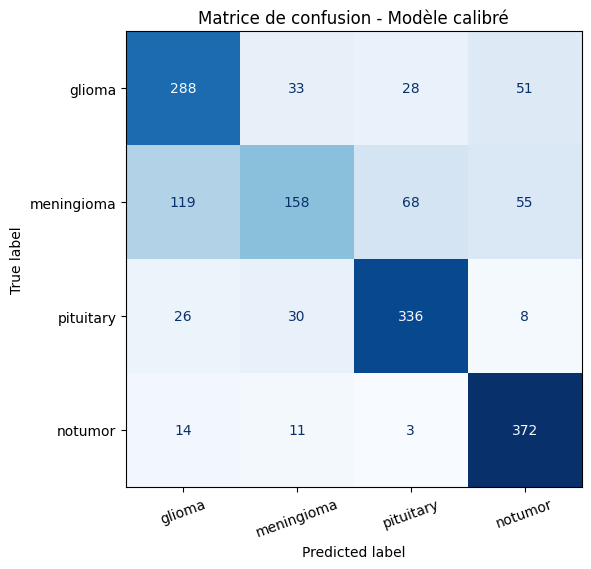

In [6]:
# Matrice de confusion du modèle calibré
cm = confusion_matrix(y_test, cal_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_split.class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matrice de confusion - Modèle calibré')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 4) Analyse de confiance et incertitude (`max_prob < 0.7`)

In [7]:
summary = predict_with_confidence(
    model=calibrated_model,
    x_data=x_test_flat,
    uncertainty_threshold=UNCERTAINTY_THRESHOLD,
)

confidence_stats = summarize_confidence_distribution(summary.max_prob)
uncertain_stats = analyze_uncertain_predictions(summary.max_prob, threshold=UNCERTAINTY_THRESHOLD)

print('Distribution max_prob:')
print('  p25={p25:.3f} | p50={p50:.3f} | p75={p75:.3f} | mean={mean:.3f} | std={std:.3f}'.format(**confidence_stats))

print('\nPrédictions incertaines:')
print(f"  Seuil={uncertain_stats['threshold']:.2f}")
print(f"  Incertaines={uncertain_stats['uncertain_count']}/{uncertain_stats['total']} ({100*uncertain_stats['uncertain_ratio']:.2f}%)")

Distribution max_prob:
  p25=0.531 | p50=0.657 | p75=0.760 | mean=0.647 | std=0.141

Prédictions incertaines:
  Seuil=0.70
  Incertaines=944/1600 (59.00%)


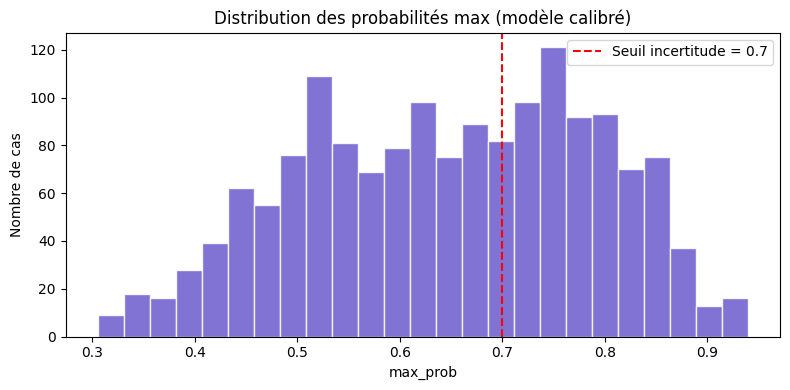

In [8]:
# Histogramme des niveaux de confiance
plt.figure(figsize=(8, 4))
plt.hist(summary.max_prob, bins=25, color='slateblue', alpha=0.85, edgecolor='white')
plt.axvline(UNCERTAINTY_THRESHOLD, color='red', linestyle='--', label=f'Seuil incertitude = {UNCERTAINTY_THRESHOLD}')
plt.title('Distribution des probabilités max (modèle calibré)')
plt.xlabel('max_prob')
plt.ylabel('Nombre de cas')
plt.legend()
plt.tight_layout()
plt.show()

## 5) Exemples de cas incertains

In [9]:
uncertain_indices = np.where(summary.uncertain_mask)[0]
print(f'Nombre de cas incertains: {len(uncertain_indices)}')

n_show = min(10, len(uncertain_indices))
if n_show == 0:
    print('Aucun cas incertain avec ce seuil.')
else:
    print('Index | Vrai label | Pred label | max_prob')
    for idx in uncertain_indices[:n_show]:
        true_label = train_split.class_names[int(y_test[idx])]
        pred_label = train_split.class_names[int(summary.y_pred[idx])]
        max_p = summary.max_prob[idx]
        print(f'{idx:>5} | {true_label:<10} | {pred_label:<10} | {max_p:.3f}')

Nombre de cas incertains: 944
Index | Vrai label | Pred label | max_prob
    1 | glioma     | glioma     | 0.644
    3 | glioma     | pituitary  | 0.356
    4 | glioma     | notumor    | 0.659
    5 | glioma     | notumor    | 0.576
    8 | glioma     | meningioma | 0.463
    9 | glioma     | glioma     | 0.676
   10 | glioma     | meningioma | 0.465
   11 | glioma     | meningioma | 0.504
   13 | glioma     | glioma     | 0.439
   15 | glioma     | glioma     | 0.572
